In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.datasets import make_moons, make_circles
from sklearn.svm import SVC

## 1. Setup and utilities

In [2]:
# Setup graphics

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,6)

The following function:
1. Simulates many points in the space (grid)
2. Use the model to classify each point
3. Shows decision regions
4. Plots real data
5. Shows support vectors

In [3]:
def plot_decision_boundary(model, X, y, title="Decision boundary"):

    # Create grid 
    y_min, y_max = X[:, 0].min() -1, X[:, 0].max() + 1
    x_min, x_max = X[:, 0].min() -1, X[:, 0].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )

    # Predictions on the grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")

    # Plot points
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="coolwarm", edgecolor="k")

    # If they exist, highligt support vectors
    if hasattr(model, "support_vectors_"):
        plt.scatter(
            model.support_vectors_[:, 0],
            model.support_vectors_[:, 1],
            s=100,
            facecolors="none",
            edgecolors="black",
            label="Support vectors"
        )

    plt.title(title)
    plt.legend()
    plt.show()

## 2. Data generation and visualization

In [4]:
# generation of two non-linear separable dataset

# Dataset 1: Moons
X_moons, y_moons = make_moons(n_samples=300, noise=0.2, random_state=42)

# dataset 2: Circles
X_circles, y_circles = make_circles(n_samples=300, noise=0.1, factor=0.5, random_state=42)

In [5]:
# Visualization

def plot_dataset(X, y, title):
    plt.figure()
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=y, palette="coolwarm", edgecolor="k")
    plt.title(title)
    plt.show()

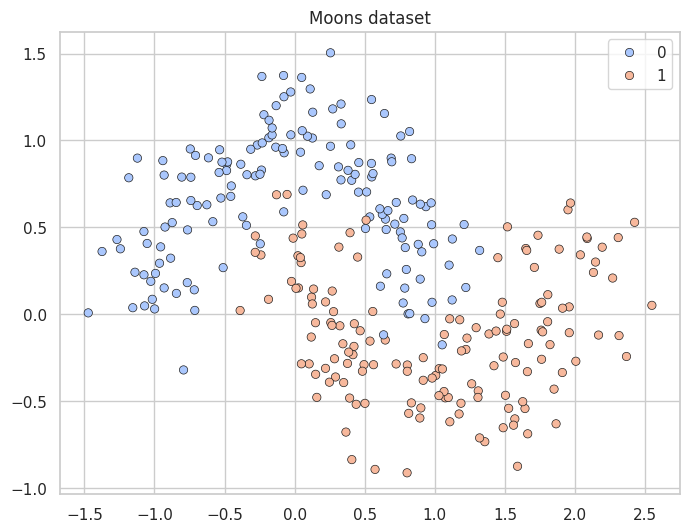

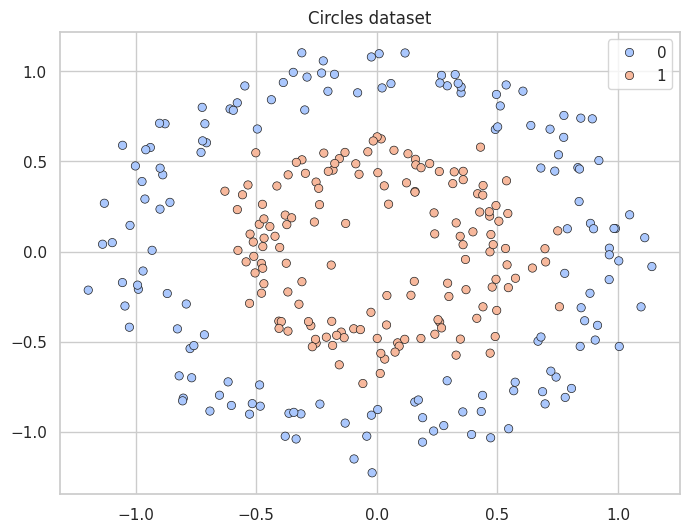

In [6]:
plot_dataset(X_moons, y_moons, "Moons dataset")
plot_dataset(X_circles, y_circles, "Circles dataset")

I generated two non linearly separable datasets: moons and circles. This choice is intentional and is meant to show that linear SVM struggles to correctly classify data. This will make me introduce kernel methods.

## 3. Linear SVM

I show how a linear model cannot separate data.

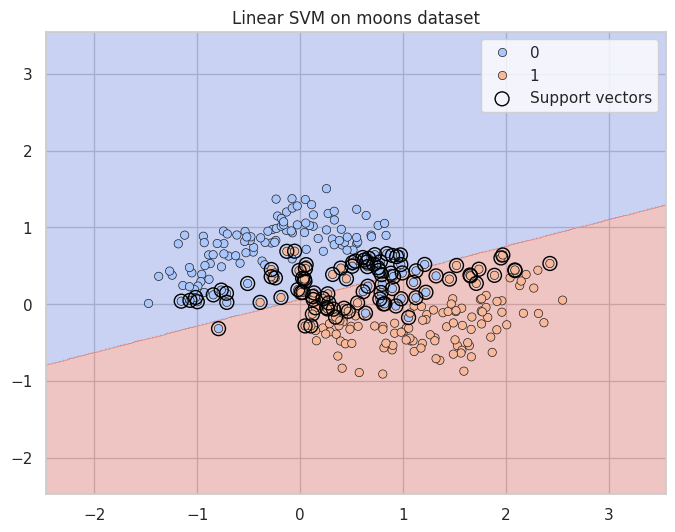

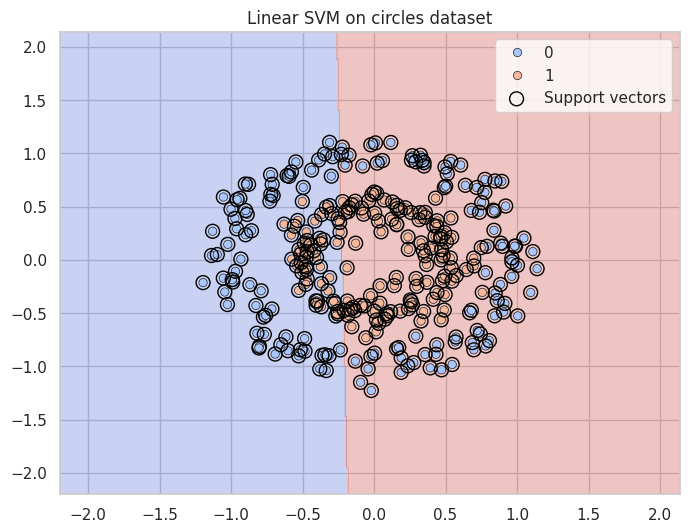

In [7]:
# Linear SVM and visualization

linear_svm_moons = SVC(kernel="linear", C=1)
linear_svm_circles = SVC(kernel="linear", C=1)

# Moons
linear_svm_moons.fit(X_moons, y_moons)
plot_decision_boundary(linear_svm_moons, X_moons, y_moons, title="Linear SVM on moons dataset")

# Circles
linear_svm_circles.fit(X_circles, y_circles)
plot_decision_boundary(linear_svm_circles, X_circles, y_circles, title="Linear SVM on circles dataset")

The linear SVM tries to separate data using straight lines, but the model fails.

In [8]:
# Accuracies

print("Moons accuracy: ", linear_svm_moons.score(X_moons, y_moons))
print("Circles accuracy: ", linear_svm_circles.score(X_circles, y_circles))

Moons accuracy:  0.8633333333333333
Circles accuracy:  0.55


The problem is the choice of the kernel (linear). In the following, I use the RBF kernel.

## 4. RBF Kernel

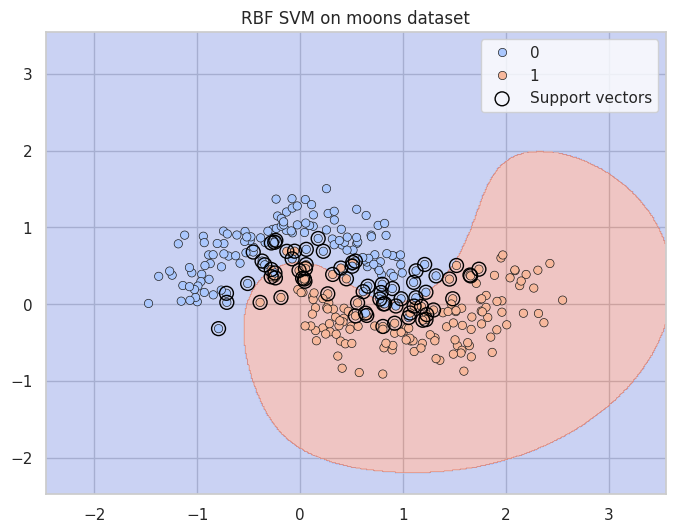

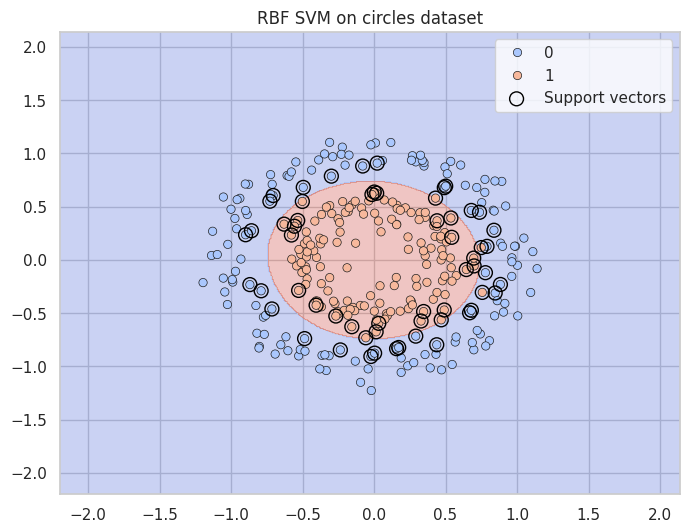

In [9]:
# RBF and visualization

rbf_svm_moons = SVC(kernel="rbf", C=1, gamma="scale")
rbf_svm_circles = SVC(kernel="rbf", C=1, gamma="scale")

# Moons
rbf_svm_moons.fit(X_moons, y_moons)
plot_decision_boundary(rbf_svm_moons, X_moons, y_moons, title="RBF SVM on moons dataset")

# Circles
rbf_svm_circles.fit(X_circles, y_circles)
plot_decision_boundary(rbf_svm_circles, X_circles, y_circles, title="RBF SVM on circles dataset")

In [10]:
# Accuracies

print("Moons accuracy RBF: ", rbf_svm_moons.score(X_moons, y_moons))
print("Circles accuracy RBF: ", rbf_svm_circles.score(X_circles, y_circles))

Moons accuracy RBF:  0.96
Circles accuracy RBF:  0.99


Model accuracies have significantly increased changing the kernel to a non linear one.

## 5. Support vectors: deep dive

In [11]:
# How many for each model?

print("Number of support vectors (moons): ", len(rbf_svm_moons.support_vectors_))
print("Number of support vectors (circles): ", len(rbf_svm_circles.support_vectors_))

Number of support vectors (moons):  71
Number of support vectors (circles):  58


These are the only significant point for the model. All the rest is ignored.

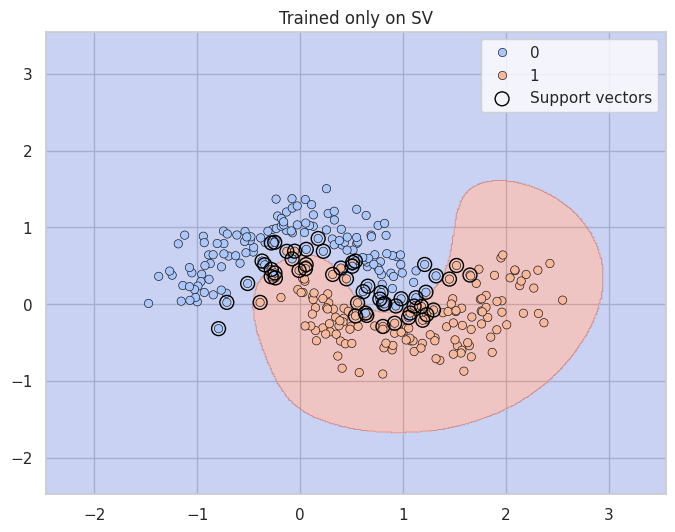

In [13]:
# Re-train only on support vectors

X_small = X_moons.copy()
y_small = y_moons.copy()

sv = rbf_svm_moons.support_

X_sv = X_small[sv]
y_sv = y_small[sv]

model_sv_only = SVC(kernel="rbf", C=1, gamma="scale")
model_sv_only.fit(X_sv, y_sv)

plot_decision_boundary(model_sv_only, X_moons, y_moons, title="Trained only on SV")

In [14]:
print("Moons accuracy RBF only on SV: ", model_sv_only.score(X_sv, y_sv))

Moons accuracy RBF only on SV:  0.8732394366197183


Even when trained on the subset of support vectors, the model achieves similar performances.

## 6. $C$ parameter effect

In general:
* Higher C -> Less errors, risk overfitting
* Smaller C -> More errors, more stable

Accuracy for C=0.01: 0.8533333333333334


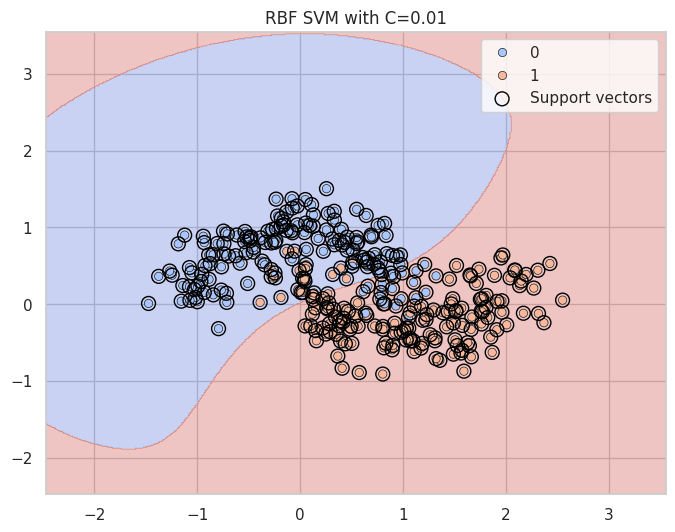

Accuracy for C=1: 0.96


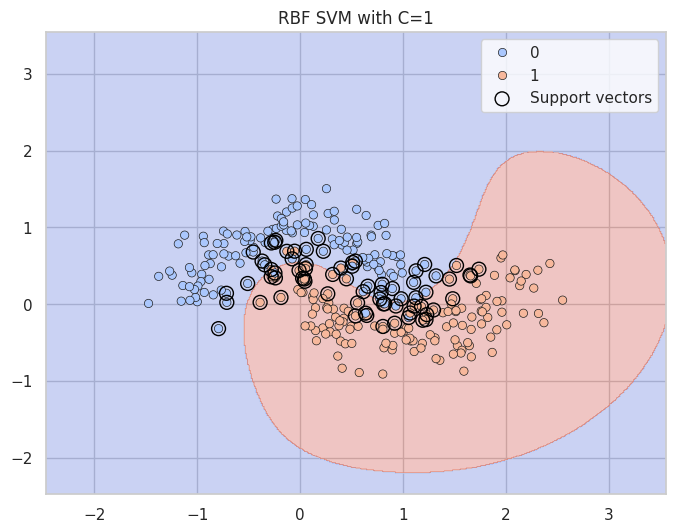

Accuracy for C=1000: 0.9766666666666667


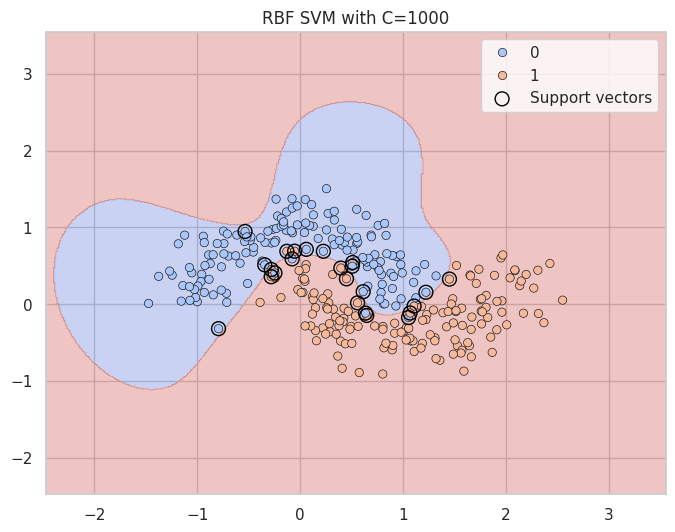

In [17]:
# Test the model for different C's

C_values = [0.01, 1, 1000]

for C in C_values:
    model = SVC(kernel="rbf", C=C, gamma="scale")
    model.fit(X_moons, y_moons)

    print(f"Accuracy for C={C}: {model.score(X_moons, y_moons)}")
    plot_decision_boundary(model, X_moons, y_moons, title=f"RBF SVM with C={C}")

Results:
* For C=0.01 the margin is very big and there is underfitting.
* For C=1 accuracy is higher.
* For C=100 the margin is thinner and there's overfitting.

## 7. $\gamma$ effects

In general:
* High $\gamma$ -> complex decision boundary, overfitting
* Low $\gamma$ -> wide decision boundary, underfitting

Accuracy for C=1000: 0.8566666666666667


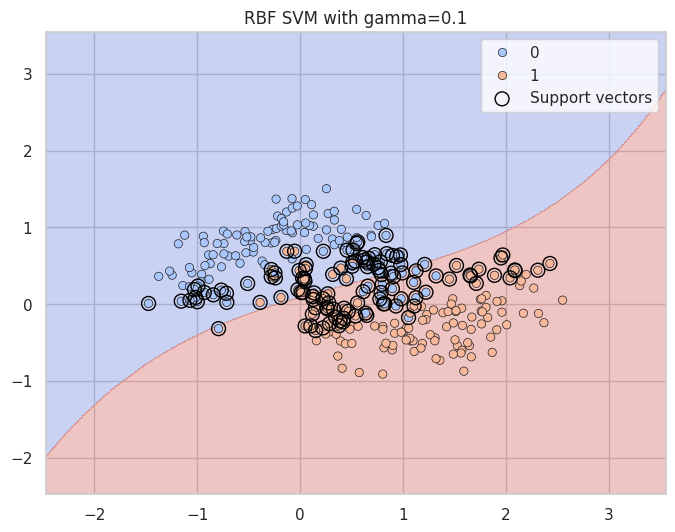

Accuracy for C=1000: 0.96


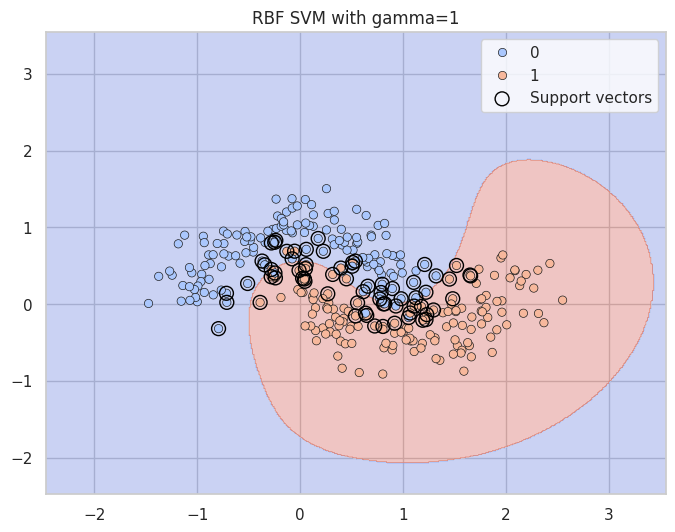

Accuracy for C=1000: 0.9766666666666667


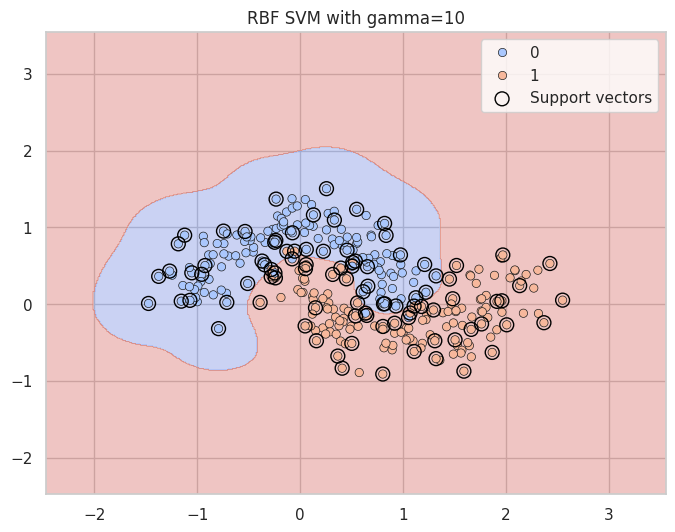

In [18]:
# Test for different gammas

gamma_values = [0.1, 1, 10]

for gamma in gamma_values:

    model = SVC(kernel="rbf", C=1, gamma=gamma)
    model.fit(X_moons, y_moons)

    print(f"Accuracy for C={C}: {model.score(X_moons, y_moons)}")
    plot_decision_boundary(model, X_moons, y_moons, title=f"RBF SVM with gamma={gamma}")

While $\gamma = 0.1$ clearly causes underfitting, $\gamma = 10$ causes overfitting. 

## 8. Final insights

In [19]:
models = {
    "Linear SVM": SVC(kernel="linear", C=1),
    "RBF (C=1, gamma=1)": SVC(kernel="rbf", C=1, gamma=1),
    "RBF (C=1000, gamma=1)": SVC(kernel="rbf", C=1000, gamma=1),
    "RBF (C=1, gamma=10)": SVC(kernel="rbf", C=1, gamma=10)
}

results = []

for name, model in models.items():
    model.fit(X_moons, y_moons)
    acc = model.score(X_moons, y_moons)

    results.append((name, acc))

for name, acc in results:
    print(f"{name}: {acc:.3f}")

Linear SVM: 0.863
RBF (C=1, gamma=1): 0.960
RBF (C=1000, gamma=1): 0.977
RBF (C=1, gamma=10): 0.977


In [20]:
df_results = pd.DataFrame(results, columns=["Model", "Accuracy"])
df_results

,Model,Accuracy
0,Linear SVM,0.863333
1,"RBF (C=1, gamma=1)",0.960000
2,"RBF (C=1000, gamma=1)",0.976667
3,"RBF (C=1, gamma=10)",0.976667


* The linear model struggles with non linear dataset, achieving a lower accuracy
* RBF kernel significantly imporves the performance
* RBF performances depend on the choice of the parameters $\gamma$ and $C$. Small values cause underfitting, high values can cause overfitting

In [22]:
# Accuracy heatmap: gamma and C

C_range = [0.01, 0.1, 1, 10, 100, 1000]
gamma_range = [0.01, 0.1, 1, 10, 100]

results = []

for C in C_range:
    for gamma in gamma_range:
        model = SVC(kernel="rbf", C=C, gamma=gamma)
        model.fit(X_moons, y_moons)
        acc = model.score(X_moons, y_moons)
        results.append((C, gamma, acc))

df = pd.DataFrame(results, columns=["C", "gamma", "accuracy"])
pivot = df.pivot(index="C", columns="gamma", values="accuracy")

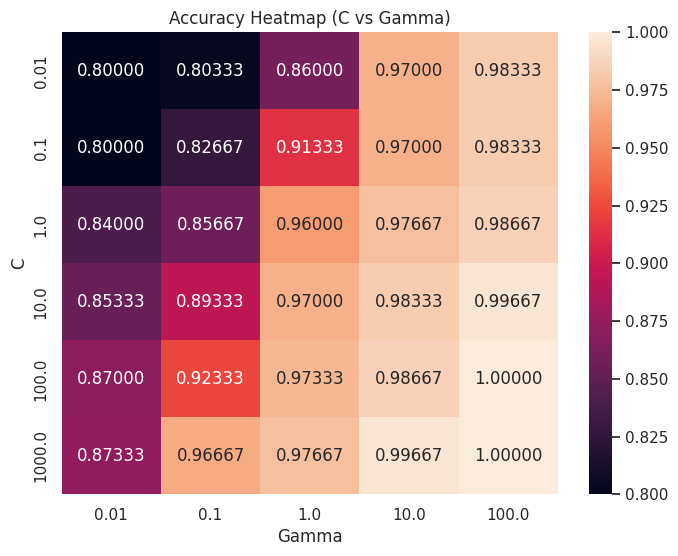

In [25]:
plt.figure()
sns.heatmap(pivot, annot=True, fmt=".5f")
plt.title("Accuracy Heatmap (C vs Gamma)")
plt.xlabel("Gamma")
plt.ylabel("C")
plt.show()